# Overview
https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python#Want-to-learn-more?

こちらを参考にして特徴量選択、欠損値補完、外れ値処理をしてみる

In [1]:
# 基本
import numpy as np
import pandas as pd

# 可視化
import matplotlib.pyplot as plt
import seaborn as sns

# 機械学習
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# 表示設定
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# モデル
import lightgbm as lgb
import catboost as cb

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

train_df.shape, test_df.shape

((1460, 81), (1459, 80))

# Sale Price観察

In [2]:
train_df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

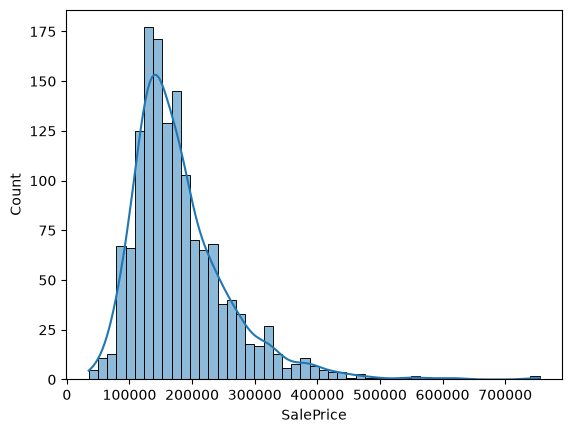

In [3]:
sns.histplot(train_df['SalePrice'], kde=True)

In [4]:
# 歪度。分布が左右どちらに歪んでいるか
print('Skewness: %f' % train_df['SalePrice'].skew())
# 尖度。尖り具合＋尻尾の重さ
print("Kurtosis: %f" % train_df['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

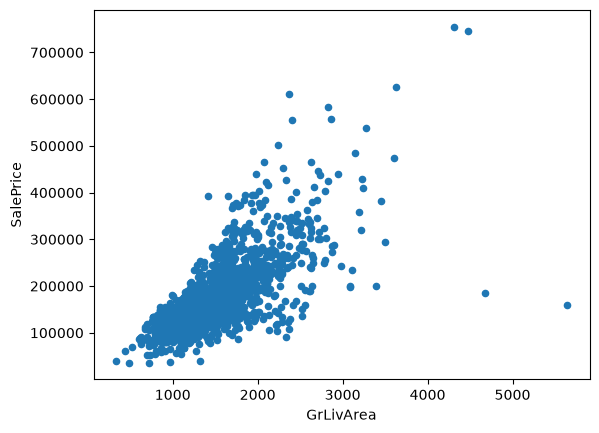

In [5]:
#scatter plot grlivarea/saleprice
var = 'GrLivArea'
data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0.800000))

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

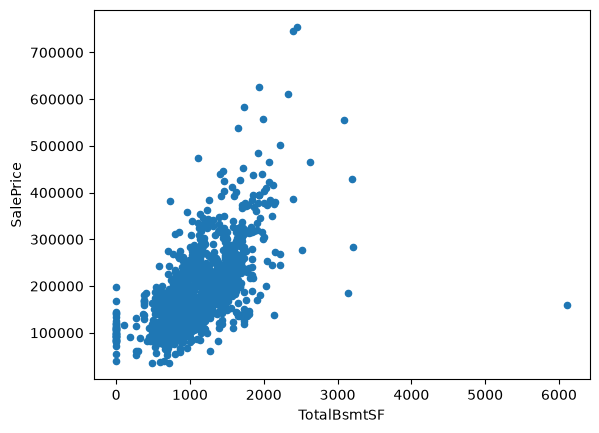

In [6]:
#scatter plot totalbsmtsf/saleprice
var = 'TotalBsmtSF'
data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0.800000))

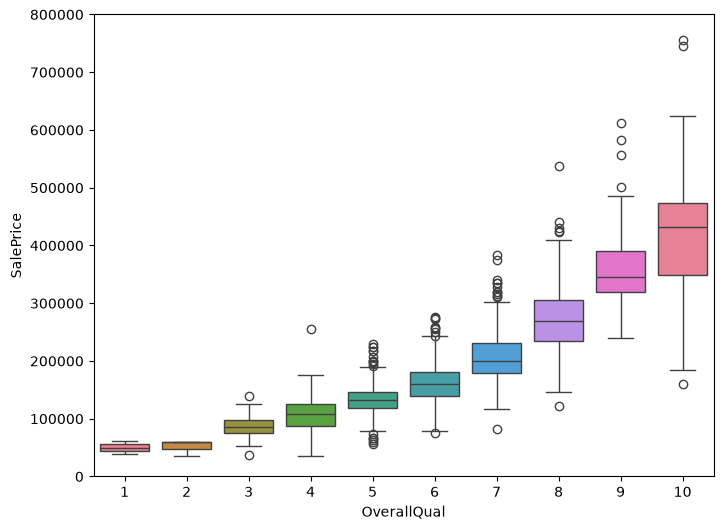

In [7]:
#box plot overallqual/saleprice
var = 'OverallQual'
data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 6))
fig = sns.boxplot(x=var, y="SalePrice", data=data, palette='husl', hue=var, legend=False)
fig.axis(ymin=0, ymax=800000);

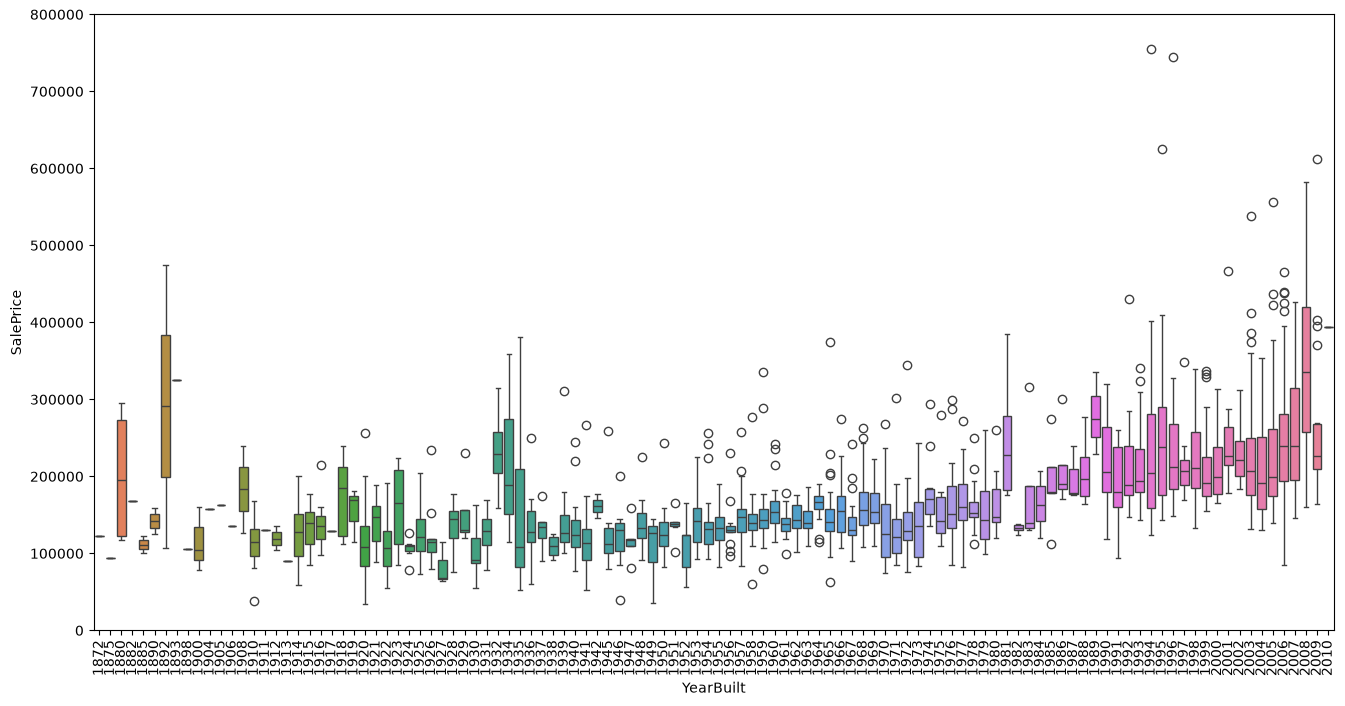

In [8]:
var = 'YearBuilt'
data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
f, ax = plt.subplots(figsize=(16, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data, palette='husl', hue=var, legend=False)
fig.axis(ymin=0, ymax=800000);
plt.xticks(rotation=90);

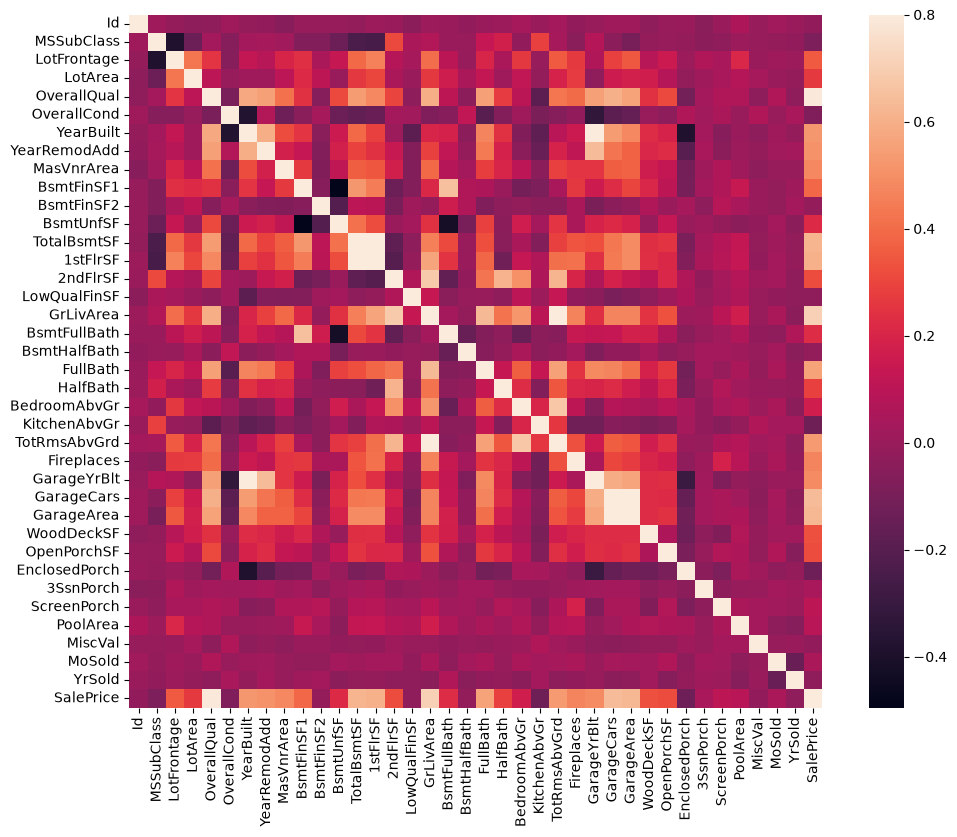

In [9]:
#correlation matrix
corrmat = train_df.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

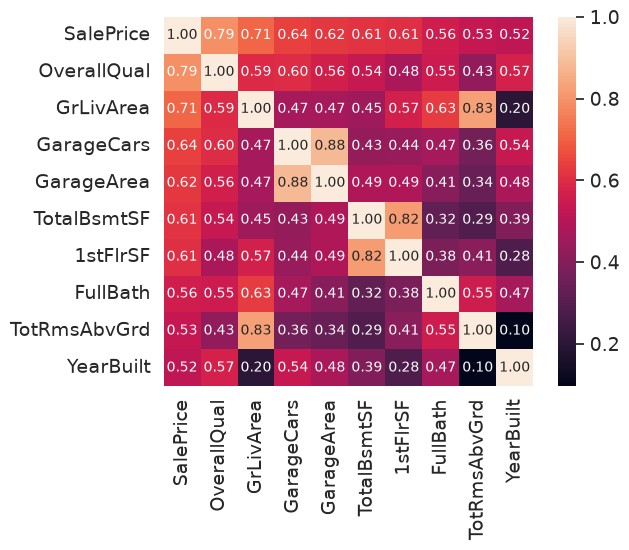

In [10]:
#saleprice correlation matrix
k = 10 #number of variables for heatmap
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(train_df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

/home/grk/kaggle/house-prices/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


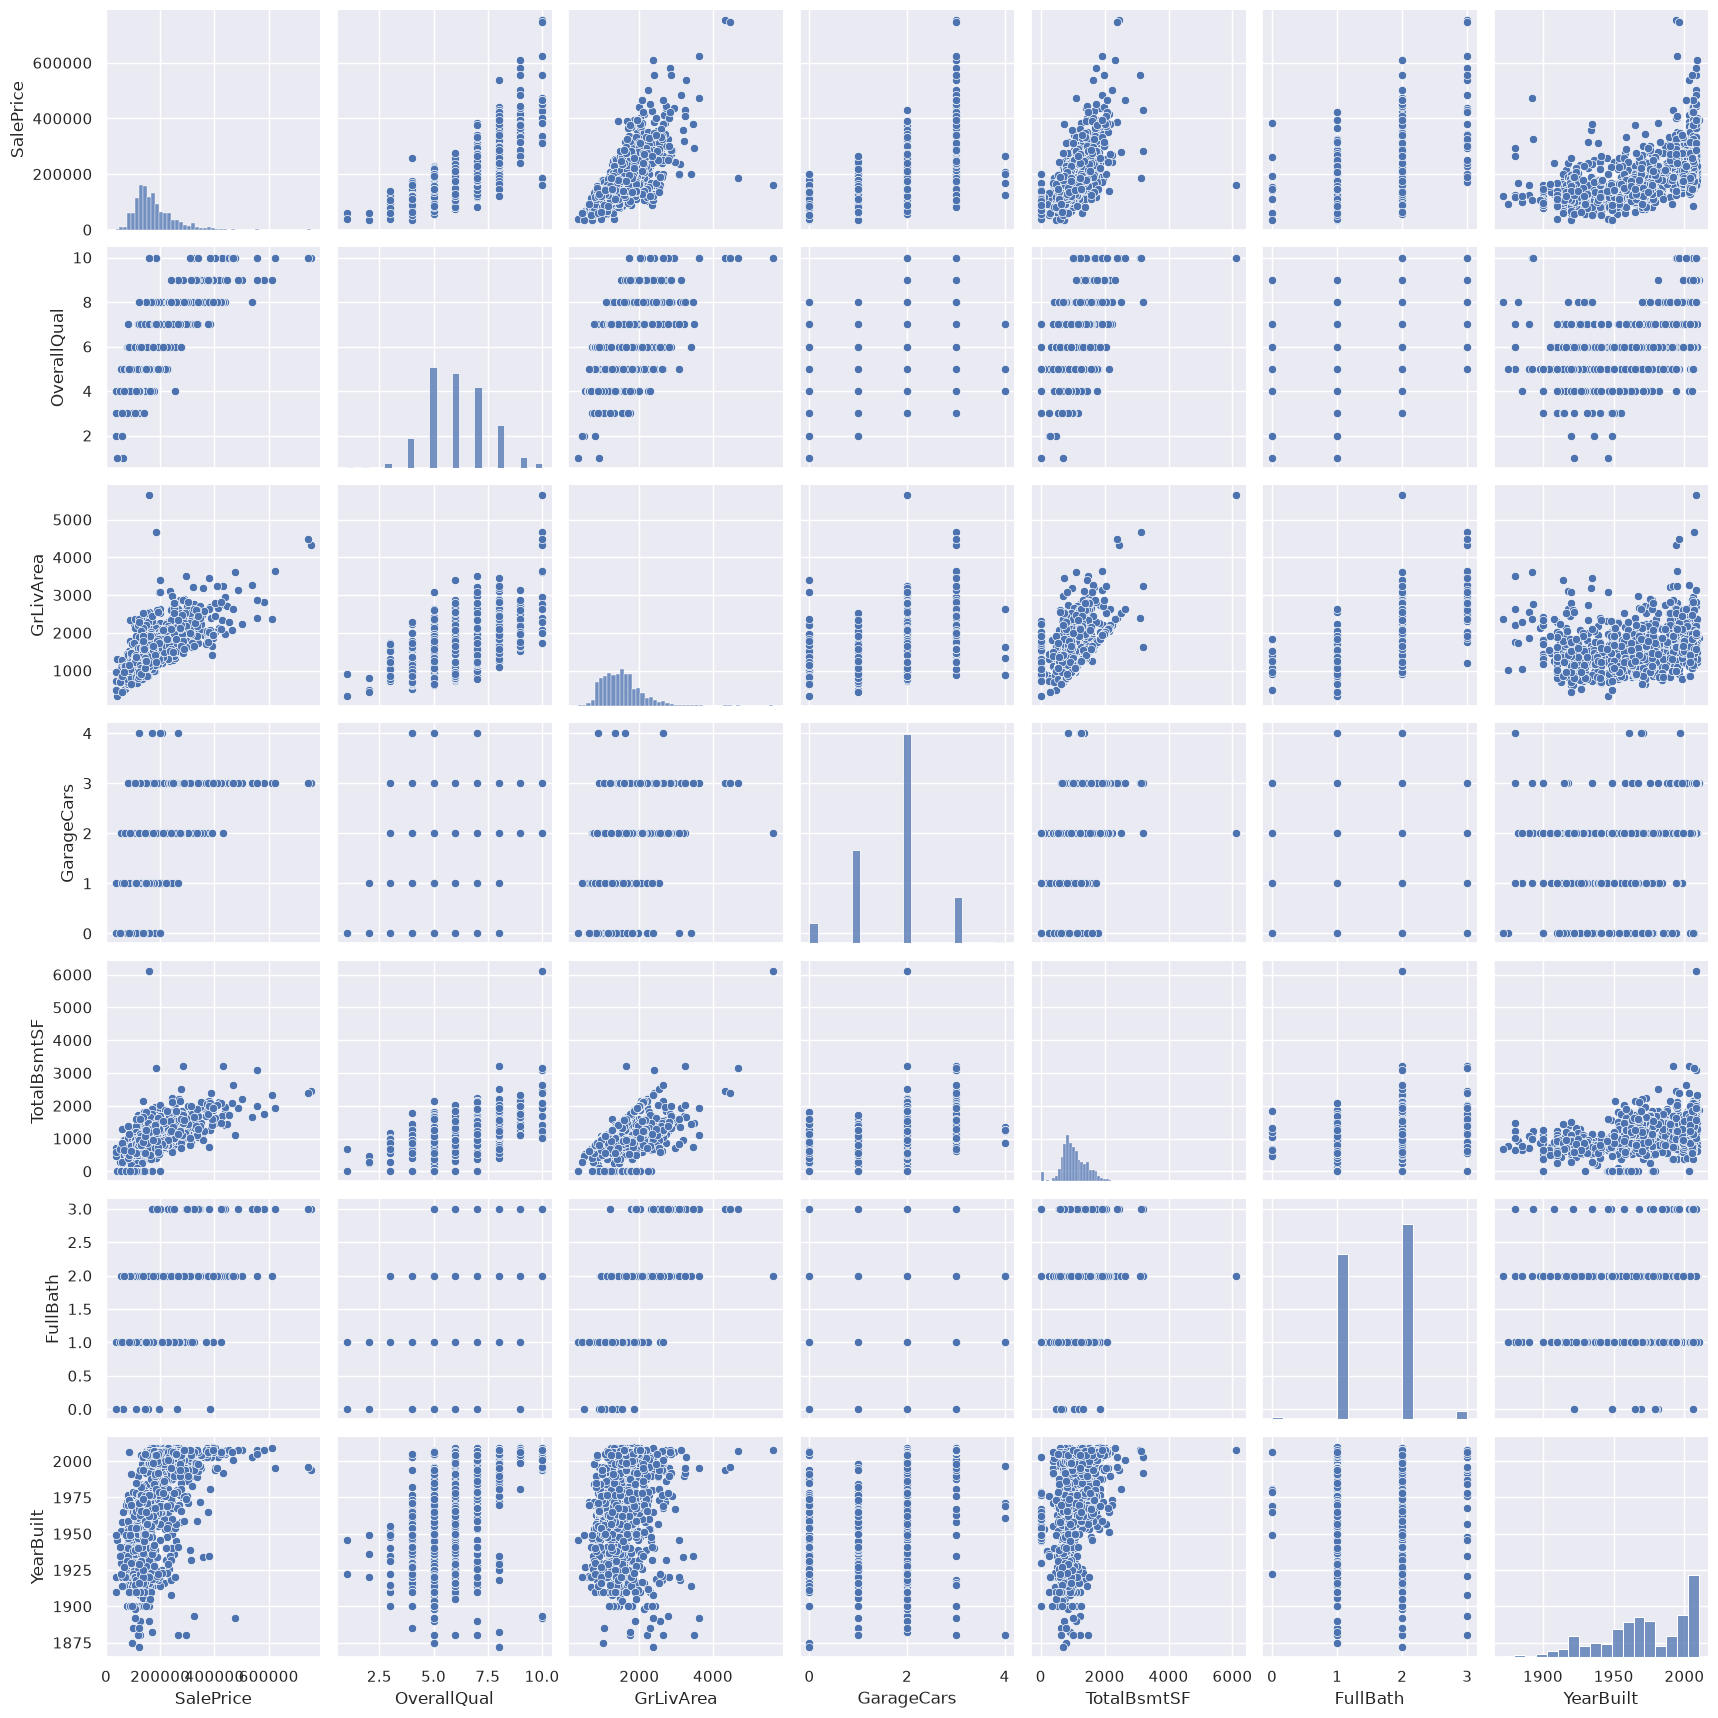

In [11]:
#scatterplot
sns.set()
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train_df[cols], size = 2.5)
plt.show();

# データ加工

In [12]:
train_df = train_df[~train_df['Id'].isin([1299, 524])].copy()
train_df = train_df.drop(train_df.loc[train_df['Electrical'].isnull()].index)

In [13]:
train_len = len(train_df)
data = pd.concat([train_df, test_df])
print(train_df.shape)
print(test_df.shape)
print(data.shape)

(1457, 81)
(1459, 80)
(2916, 81)


In [14]:
# # 家全体の広さを特徴量にする
# data['TotalSF'] = (
#   data['TotalBsmtSF']
#   + data['1stFlrSF']
#   + data['2ndFlrSF']
# )

In [15]:
#missing data
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum()/train_df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1451,0.995882
MiscFeature,1403,0.962938
Alley,1366,0.937543
Fence,1176,0.807138
MasVnrType,871,0.597804
FireplaceQu,689,0.472889
LotFrontage,259,0.177763
GarageQual,81,0.055594
GarageFinish,81,0.055594
GarageType,81,0.055594


In [16]:
#dealing with missing data
drop_columns = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence',
    'MasVnrType',
    'FireplaceQu',
    'LotFrontage',
    'GarageQual',
    'GarageFinish',
    'GarageType',
    'GarageYrBlt',
    'GarageCond',
    'BsmtFinType2',
    'BsmtExposure',
    'BsmtCond',
    'BsmtQual',
    'BsmtFinType1',
    'MasVnrArea'
]
data = data.drop(columns=drop_columns)

data.isnull().sum().max() #just checking that there's no missing data missing...

np.int64(1459)

In [17]:
#standardizing data
from sklearn.preprocessing import StandardScaler

saleprice_scaled = StandardScaler().fit_transform(
    train_df[['SalePrice']]
)

low_range = saleprice_scaled[saleprice_scaled[:, 0].argsort()][:10]
high_range = saleprice_scaled[saleprice_scaled[:, 0].argsort()][-10:]

print('outer range (low) of the distribution:')
print(low_range)

print('\nouter range (high) of the distribution:')
print(high_range)

outer range (low) of the distribution:
[[-1.83714031]
 [-1.83197013]
 [-1.79940175]
 [-1.78179041]
 [-1.77298475]
 [-1.62203048]
 [-1.61574072]
 [-1.58429192]
 [-1.58429192]
 [-1.57180045]]

outer range (high) of the distribution:
[[3.82490259]
 [4.036704  ]
 [4.49161726]
 [4.70546914]
 [4.72535736]
 [5.05685293]
 [5.41818712]
 [5.58603569]
 [7.09557834]
 [7.22137356]]


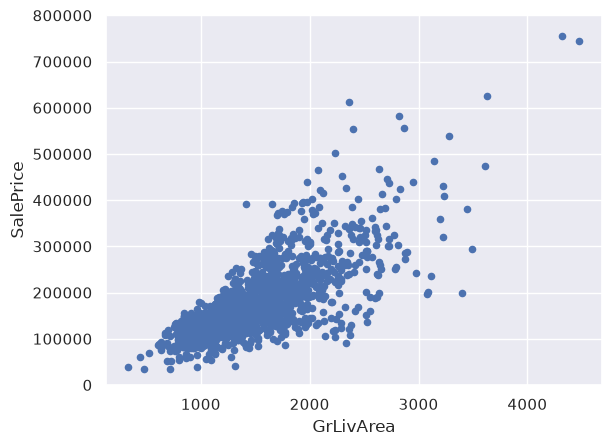

In [18]:
#bivariate analysis saleprice/grlivarea
var = 'GrLivArea'
d = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
d.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

In [19]:
#deleting points
train_df.sort_values(by = 'GrLivArea', ascending = False)[:2]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1996,1996,Hip,CompShg,Wd Sdng,ImStucc,NaN,0.0,Gd,TA,PConc,Ex,TA,Av,GLQ,2096,Unf,0,300,2396,GasA,Ex,Y,SBrkr,2411,2065,0,4476,1,0,3,1,4,1,Ex,10,Typ,2,TA,Attchd,1996.0,Fin,3,813,TA,TA,Y,171,78,0,0,0,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,6,1994,1995,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455,Unf,0,989,2444,GasA,Ex,Y,SBrkr,2444,1872,0,4316,0,1,3,1,4,1,Ex,10,Typ,2,Ex,Attchd,1994.0,Fin,3,832,TA,TA,Y,382,50,0,0,0,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


In [20]:
# data = data.drop(train_df[train_df['Id'] == 1299].index)
# data = data.drop(train_df[train_df['Id'] == 524].index)

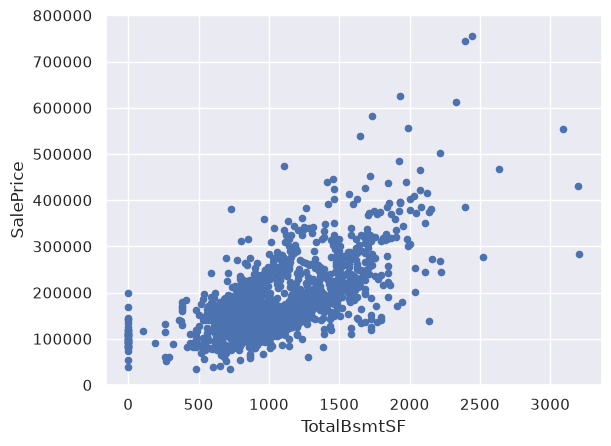

In [21]:
#bivariate analysis saleprice/grlivarea
var = 'TotalBsmtSF'
d = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
d.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

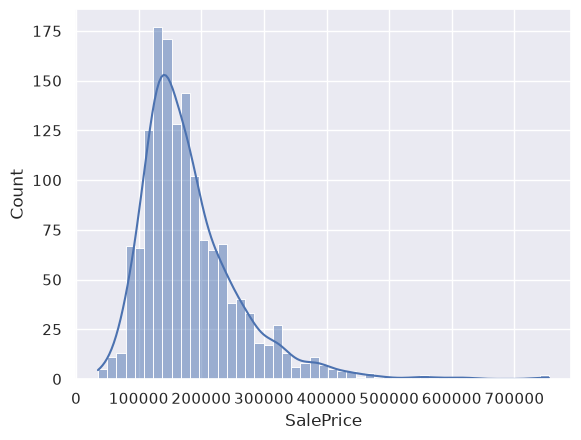

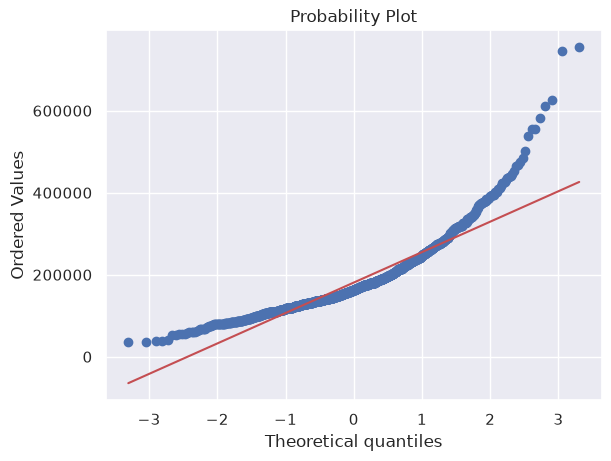

In [22]:
from scipy import stats

sns.histplot(train_df['SalePrice'], kde=True)
plt.show()

stats.probplot(train_df['SalePrice'], plot=plt)
plt.show()

In [23]:
#applying log transformation
data['SalePrice'] = np.log(data['SalePrice'])

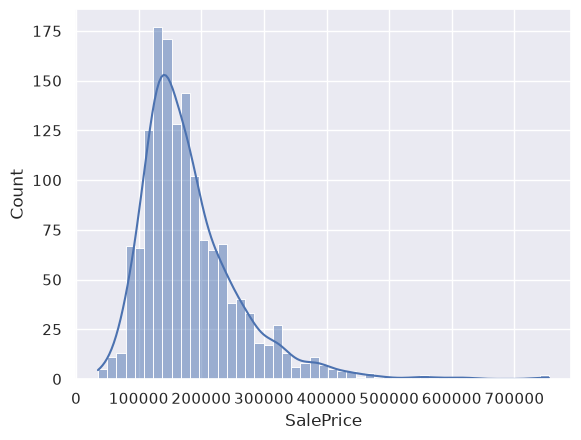

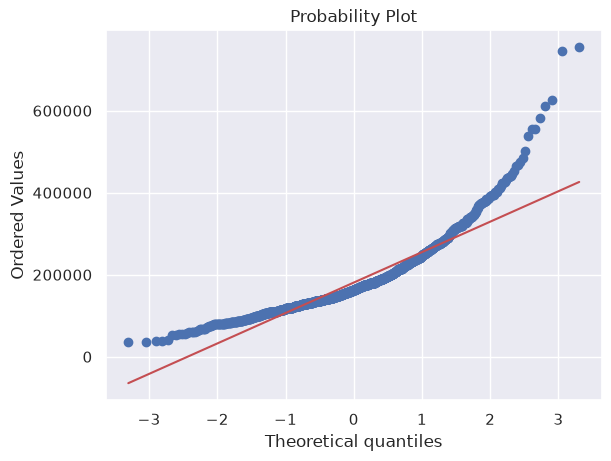

In [24]:
sns.histplot(train_df['SalePrice'], kde=True)
plt.show()

stats.probplot(train_df['SalePrice'], plot=plt)
plt.show()

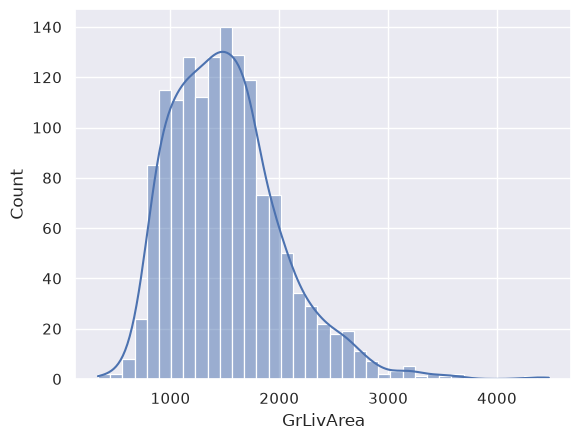

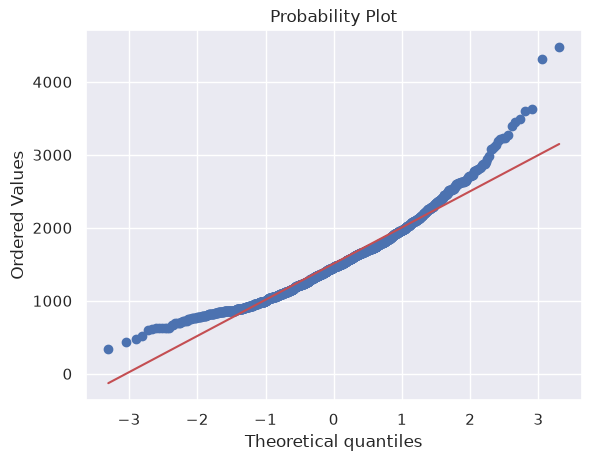

In [25]:
sns.histplot(train_df['GrLivArea'], kde=True)
plt.show()

stats.probplot(train_df['GrLivArea'], plot=plt)
plt.show()

In [26]:
#data transformation
data['GrLivArea'] = np.log(data['GrLivArea'])

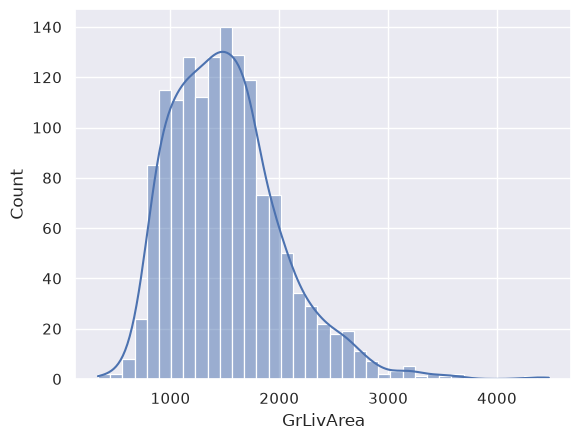

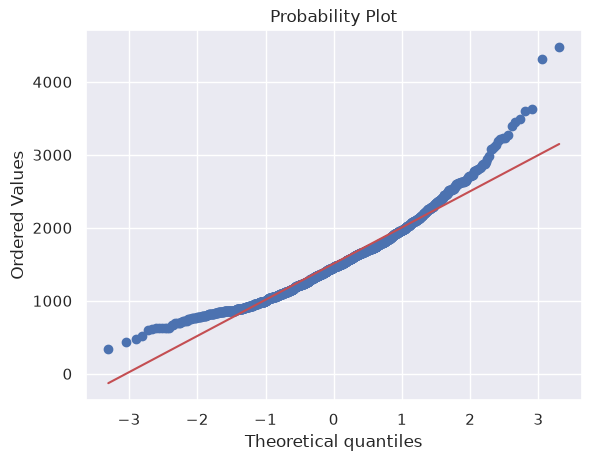

In [27]:
sns.histplot(train_df['GrLivArea'], kde=True)
plt.show()

stats.probplot(train_df['GrLivArea'], plot=plt)
plt.show()

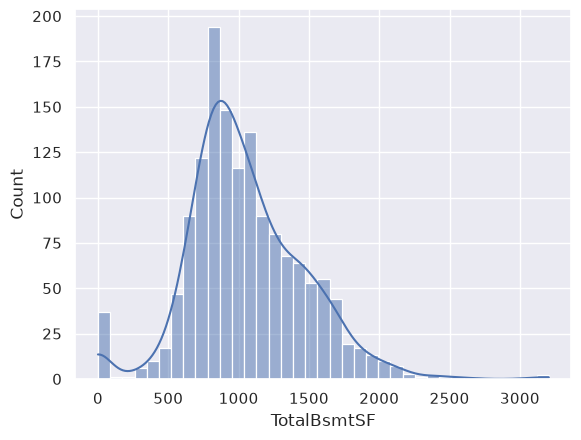

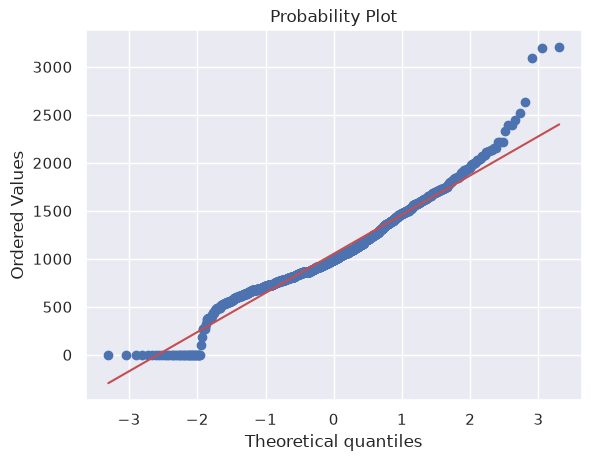

In [28]:
sns.histplot(train_df['TotalBsmtSF'], kde=True)
plt.show()

stats.probplot(train_df['TotalBsmtSF'], plot=plt)
plt.show()

In [29]:
data['TotalBsmtSF'] = np.log1p(data['TotalBsmtSF'])

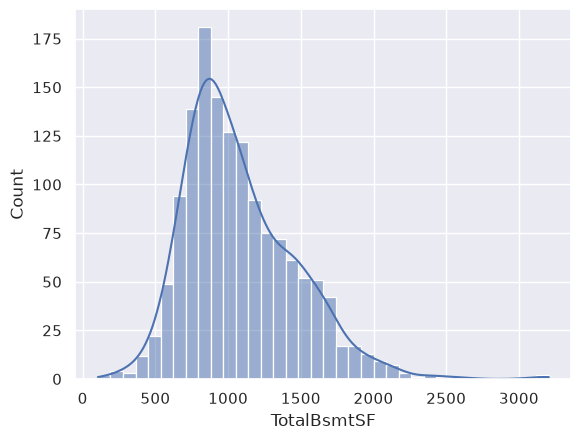

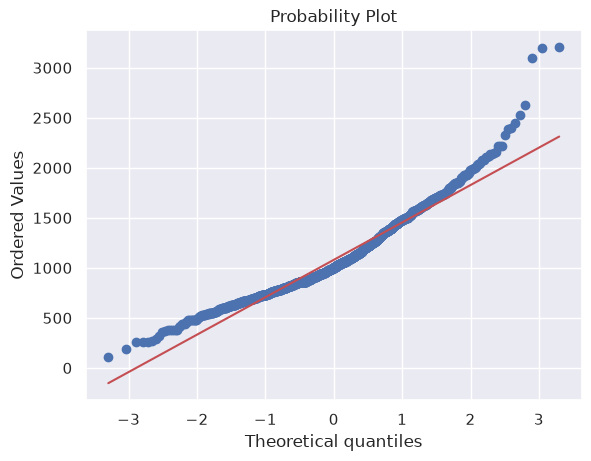

In [30]:
# 地下室ありのデータだけ
bsmt = train_df.loc[train_df['TotalBsmtSF'] > 0, 'TotalBsmtSF']

# histogram
sns.histplot(bsmt, kde=True)
plt.show()

# normal probability plot
fig = plt.figure()
stats.probplot(bsmt, plot=plt)
plt.show()

str → category型にキャストする

In [31]:
# カテゴリ列をcategory型にする
cat_cols = data.select_dtypes(include=["object", "str"]).columns

for col in cat_cols:
  data[col] = data[col].astype("category")

trainとtestをわける（もどす）

In [32]:
train_df = data.iloc[:train_len].copy()
test_df = data.iloc[train_len:].copy()

train_df.shape, test_df.shape

((1457, 63), (1459, 63))

訓練用データの準備をする

In [33]:
train_df['SalePrice'].tail()

1455    12.072541
1456    12.254863
1457    12.493130
1458    11.864462
1459    11.901583
Name: SalePrice, dtype: float64

In [34]:
X_train = train_df.drop(columns='SalePrice')
# y_train = np.log1p(train_df['SalePrice'])
y_train = train_df['SalePrice']

X_train.shape, y_train.shape

((1457, 62), (1457,))

In [35]:
train_cat_df = train_df.drop(columns="SalePrice").copy()
test_cat_df = test_df.drop(columns="SalePrice").copy()



# 最初に目的変数を確保
y_train_cat = train_df["SalePrice"].copy()

train_len = len(train_cat_df)

data = pd.concat(
    [train_cat_df, test_cat_df],
    ignore_index=True
)

cat_cols = train_cat_df.select_dtypes(
    include=["category"]
).columns.tolist()

for col in cat_cols:
    data[col] = (
        data[col]
        .cat.add_categories(["Missing"])
        .fillna("Missing")
    )

X_train_cat = data.iloc[:train_len].copy()
X_test_cat = data.iloc[train_len:].copy()


print(y_train_cat.tail())
print(y_train_cat.isnull().sum())
print(X_train_cat.shape, y_train_cat.shape)

1455    12.072541
1456    12.254863
1457    12.493130
1458    11.864462
1459    11.901583
Name: SalePrice, dtype: float64
0
(1457, 62) (1457,)


In [36]:
print(train_df.shape)
print(train_df["SalePrice"].tail(10))
print(train_df["SalePrice"].isnull().sum())

(1457, 63)
1450    11.820410
1451    12.567551
1452    11.884489
1453    11.344507
1454    12.128111
1455    12.072541
1456    12.254863
1457    12.493130
1458    11.864462
1459    11.901583
Name: SalePrice, dtype: float64
0


In [37]:
# X_train_cat = train_cat_df.drop(columns="SalePrice")
# # y_train_cat = np.log1p(train_cat_df['SalePrice'])
# y_train_cat = train_cat_df['SalePrice']

# X_train_cat.shape, y_train_cat.shape

# Training
lightGBMにデータ全部入れる

In [38]:
params = {
  "boosting_type": "gbdt",
  "objective": "regression",
  "metric": "rmse",
  "num_iterations": 1000,
  "learning_rate": 0.02,
  "num_leaves": 16,
  "max_depth": -1,
  "min_data_in_leaf": 20,
  "min_sum_hessian_in_leaf": 1e-3,
  "bagging_fraction": 0.9,
  "bagging_freq": 1,
  "feature_fraction": 0.9,
  "lambda_l1": 0.0,
  "lambda_l2": 0.0,
  "random_state": 42,
  "verbosity": -1
}

lgb_model = lgb.LGBMRegressor(**params)
lgb_model.fit(X_train, y_train)

,num_leaves,16
,learning_rate,0.02
,objective,'regression'
,random_state,42
,metric,'rmse'
,num_iterations,1000
,min_data_in_leaf,20
,min_sum_hessian_in_leaf,0.001
,bagging_fraction,0.9
,bagging_freq,1
,feature_fraction,0.9


In [39]:
print(y_train_cat.isnull().sum())


0


In [40]:
print(y_train_cat.tail(10))

1450    11.820410
1451    12.567551
1452    11.884489
1453    11.344507
1454    12.128111
1455    12.072541
1456    12.254863
1457    12.493130
1458    11.864462
1459    11.901583
Name: SalePrice, dtype: float64


**Cat Boost**を使ってみる

In [41]:
# CatBoost
cat_boost_model = cb.CatBoostRegressor(
  iterations=1000,
  learning_rate=0.03,
  depth=6,
  loss_function="RMSE",
  verbose=False
)

cat_boost_model.fit(
  X_train_cat,
  y_train_cat,
  cat_features=cat_cols
)

CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.03, loss_function='RMSE', verbose=False)

# CV
回帰なので**KFold**

In [42]:
# lightGBM
kf = KFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

scores = cross_val_score(
  lgb_model,
  X_train,
  y_train,
  cv=kf,
  scoring='neg_root_mean_squared_error'
)

rmse_scores = -scores
print(rmse_scores)

# base lineとの比較
current_lgbm_rmse = rmse_scores.mean()
prev_lgbm_rmse = 0.127711720813

improvement = prev_lgbm_rmse - current_lgbm_rmse
improvement_rate = improvement / prev_lgbm_rmse * 100

print('-'*20)
print(f"Prev LGBM RMSE : {prev_lgbm_rmse:.12f}")
print(f"Current LGBM RMSE  : {current_lgbm_rmse:.12f}")
print(f"Improvement   : {improvement:+.12f}")
print(f"Improvement % : {improvement_rate:+.2f}%")
print('-'*20)

[0.1319972  0.11399341 0.12128634 0.12553527 0.11431364]
--------------------
Prev LGBM RMSE : 0.127711720813
Current LGBM RMSE  : 0.121425173820
Improvement   : +0.006286546993
Improvement % : +4.92%
--------------------


In [43]:
# CatBoost
kf = KFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

scores = cross_val_score(
  cat_boost_model,
  X_train_cat,
  y_train_cat,
  cv=kf,
  scoring='neg_root_mean_squared_error',
  params={
    "cat_features": cat_cols  # cross_val_score内でfitするときにカテゴリ列のリストが必要
  }
)

rmse_scores = -scores
print(rmse_scores)

# base lineとの比較
current_cat_rmse = rmse_scores.mean()
prev_cat_rmse = 0.125420769766

improvement = prev_cat_rmse - current_cat_rmse
improvement_rate = improvement / prev_cat_rmse * 100

print('-'*20)
print(f"Prev CAT RMSE : {prev_cat_rmse:.12f}")
print(f"Current CAT RMSE  : {current_cat_rmse:.12f}")
print(f"Improvement   : {improvement:+.12f}")
print(f"Improvement % : {improvement_rate:+.2f}%")
print('-'*20)

[0.12284322 0.11781582 0.11549598 0.12721569 0.1052888 ]
--------------------
Prev CAT RMSE : 0.125420769766
Current CAT RMSE  : 0.117731900587
Improvement   : +0.007688869179
Improvement % : +6.13%
--------------------


In [44]:
# LGBM_WEIGHT = 0.4
# CAT_BOOST_WEIGHT = 0.6
LGBM_WEIGHT = 0.5
CAT_BOOST_WEIGHT = 0.5
# LGBM_WEIGHT = 0.3
# CAT_BOOST_WEIGHT = 0.7

# EnsembleのRMSEスコアを出したい。

In [45]:
kf = KFold(
  n_splits=5,
  shuffle=True,
  random_state=1
)

ensemble_scores = []

for train_idx, val_idx in kf.split(X_train):
  X_tr = X_train.iloc[train_idx]
  X_va   = X_train.iloc[val_idx]

  y_tr = y_train.iloc[train_idx]
  y_va   = y_train.iloc[val_idx]

  X_tr_cat = X_train_cat.iloc[train_idx]
  X_va_cat   = X_train_cat.iloc[val_idx]

  # Learning
  lgb_model.fit(X_tr, y_tr)

  cat_boost_model.fit(
      X_tr_cat,
      y_tr,
      cat_features=cat_cols
  )

  # Prediction
  lgb_pred_log = lgb_model.predict(X_va)
  cat_pred_log = cat_boost_model.predict(X_va_cat)

  # Ensemble
  ensemble_pred_log = (
    LGBM_WEIGHT * lgb_pred_log
    + CAT_BOOST_WEIGHT * cat_pred_log
  )

  # Scoring
  ensemble_rmse = root_mean_squared_error(
    y_va,
    ensemble_pred_log
  )

  ensemble_scores.append(ensemble_rmse)

# export logs
prev_ens_rmse = 0.123029441999
print(ensemble_scores)

current_ens_rmse = np.mean(ensemble_scores)

improvement = prev_ens_rmse - current_ens_rmse
improvement_rate = improvement / prev_ens_rmse * 100

print("===== ENSEMBLE CV RESULT =====")
print(f"Prev RMSE        : {prev_ens_rmse:.12f}")
print(f"Current RMSE     : {current_ens_rmse:.12f}")
print(f"Improvement      : {improvement:+.12f}")
print(f"Improvement rate : {improvement_rate:+.2f}%")

[0.12028878223446951, 0.12461729915090904, 0.11193041758955403, 0.09859403422430188, 0.12210737173225539]
===== ENSEMBLE CV RESULT =====
Prev RMSE        : 0.123029441999
Current RMSE     : 0.115507580986
Improvement      : +0.007521861013
Improvement rate : +6.11%


# Submission
lightGBMとCat Boostのアンサンブル

In [46]:
# CV終了後、全trainで再学習
lgb_model.fit(X_train, y_train)

cat_boost_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_cols
)

# Prediction
test_lgb = test_df.drop(columns="SalePrice")

lgb_pred_log = lgb_model.predict(test_lgb)
cat_pred_log = cat_boost_model.predict(X_test_cat)

# CVと同じ空間でアンサンブル
ensemble_pred_log = (
    LGBM_WEIGHT * lgb_pred_log
    + CAT_BOOST_WEIGHT * cat_pred_log
)

# 元のSalePriceへ
pred = np.exp(ensemble_pred_log)

submission = pd.DataFrame({
    "Id": test_lgb["Id"],
    "SalePrice": pred
})

submission.to_csv(
    "../submissions/submission.csv",
    index=False
)

In [47]:
submission.shape

(1459, 2)